# Индустрия маркетплейсов

## 1. Загрузка данных и знакомство с ними

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [3]:
# Выгружаем данные в переменные bank_df и clients_df
try:
    # Попытка загрузить файл по локальному пути в текущей папке
    categories = pd.read_csv('bi-analyst-categories.csv')
    order_items = pd.read_csv('bi-analyst-order_items.csv')
    orders = pd.read_csv('bi-analyst-orders.csv')
    products = pd.read_csv('bi-analyst-products.csv')
    reviews = pd.read_csv('bi-analyst-reviews.csv')
    transactions = pd.read_csv('bi-analyst-transactions.csv')
    users = pd.read_csv('bi-analyst-users.csv')
    
except FileNotFoundError:
    # Альтернативный путь для сервера
    categories = pd.read_csv('https://code.s3.yandex.net/datasets/bi-analyst-categories.csv')
    order_items = pd.read_csv('https://code.s3.yandex.net/datasets/bi-analyst-order_items.csv')
    orders = pd.read_csv('https://code.s3.yandex.net/datasets/bi-analyst-orders.csv')
    products = pd.read_csv('https://code.s3.yandex.net/datasets/bi-analyst-products.csv')
    reviews = pd.read_csv('https://code.s3.yandex.net/datasets/bi-analyst-reviews.csv')
    transactions = pd.read_csv('https://code.s3.yandex.net/datasets/bi-analyst-transactions.csv')
    users = pd.read_csv('https://code.s3.yandex.net/datasets/bi-analyst-users.csv')

In [5]:
# Выводим первые строки датафрейма на экран
categories.head()

,category_id,name,parent_category_id
0,0,Available,NaN
1,1,Imagine,NaN
2,2,Civil,1238.0
3,3,Six,243.0
4,4,NaN,NaN


In [6]:
order_items.head()

,order_item_id,order_id,product_id,quantity,price_at_order_time
0,4633224a-eb5b-4c2e-a568-8e5f3676d839,98895f4d-611c-41d2-88f5-78a5b58c78b5,ba66791e-60f0-43f2-8d1d-a84e6b047657,2,279.71
1,d68dbbb4-0323-447f-9afb-9e2def518732,fbc1d88b-aa81-43e6-b156-b2f4a8d9ec8a,e0a10065-76ac-4557-8638-2dfe422f415f,1,314.66
2,d38e7218-e244-4afe-97f9-0ba0492eaf57,fbc1d88b-aa81-43e6-b156-b2f4a8d9ec8a,0d122bb3-888c-4fcc-8609-057c9c3ed2e8,3,145.99
3,ab970c22-4625-4944-9e73-5fdbc04a9928,fbc1d88b-aa81-43e6-b156-b2f4a8d9ec8a,ef894d8e-a749-43a8-9486-6bbfe247364a,1,955.55
4,0ffc4785-c391-48c6-932d-e85e0c552c97,928d50b8-ab93-46dc-ac42-3e57224bd0b6,ac47bd16-2356-4086-b94d-3f1b5d090174,1,585.98


In [7]:
orders.head()

,order_id,buyer_id,order_date,status,total_amount
0,2299f3d1-f01e-4d6a-ad54-c9a74bff0c02,bc69766f-aab2-469c-b24f-4b00151aa519,2025-04-27 10:27:18.000,paid,4674.51
1,186fdd71-4ddf-4198-9162-c71febc7bc05,e421a631-2faf-4810-8a81-7f377d728eff,2025-02-24 15:08:42.000,new,1575.70
2,4ab13c5e-924a-43f1-a77a-17d28bd0f6f6,319b30cf-0ef0-4e8e-a1bc-ca83136b59cc,2024-01-16 04:13:06.000,canceled,2048.65
3,11bd972e-20a2-4ce7-96fb-bb4ed47c4614,fbff34d4-644d-456b-9331-833d1aa58a9e,2025-04-09 09:32:46.000,shipped,5267.75
4,2ff312f2-e2a2-4b17-a94c-e29211206728,7651578e-fa3b-4888-9000-2d1e607712cf,2025-06-08 12:58:51.000,shipped,1560.81


In [10]:
products.head()

,product_id,title,description,category_id,price,stock_quantity,seller_id
0,eabfaf47-5fe4-466c-ba3d-026f0f4b13f4,Amount,War nor provide situation. Break concern final.,230,825.25,892,3b3d1b4e-3317-43f6-871a-94fea2cbcf30
1,966d61df-3cbd-4239-92b8-d9a0a7485874,Least,Allow recognize western six campaign including.,632,523.01,269,24ca1b48-5ab3-4498-8c64-115d96c669a9
2,b77f8466-3068-4d38-aed3-b5db8e8c14db,Simply,Authority deal space few.,528,842.30,730,cc334b15-6fc9-40c4-9355-f70a41b0d92e
3,f9fd17e7-435a-40db-816d-3d74f59f61b8,Lawyer,Difficult rise politics cell.,512,896.47,775,907fecb4-545b-46e9-bc2a-fda54ffed199
4,7a795939-fba8-4377-9761-b5c2a4afbdea,Keep,Worker rest whether bit arm issue everyone.,1137,943.10,543,510a9e6f-4018-4fcb-a50e-5e8dadd44ab5


In [9]:
reviews.head()

,review_id,user_id,product_id,rating,comment,review_date
0,92e9eb35-0063-448c-a407-47e99530eb99,5fcf22b3-2788-4102-a3f4-7721d92d923f,77ac4b77-b310-47cc-873b-66e6a0ced5a1,2,Another gun wide read former.,2025-02-12 05:12:04.000
1,78864309-374c-4499-adbd-63e7ed1f604e,0f1a1211-70c9-42ec-8dca-1c56b9bd8206,13c4fcfe-bd79-49ac-a666-1e19507b9896,3,Ahead offer such when.,2024-07-05 16:19:28.000
2,239fea6e-b3aa-4786-8bff-563bae3400c4,f59d2104-5752-4b16-91be-b2dec691c978,5dcf670c-c917-43e4-859b-86cbc78cfef1,2,Type require now appear.,2024-01-29 02:48:17.000
3,b7e67361-947c-48cd-8586-be4806a0d460,5bce0123-4c46-4aef-a71a-02b276a47f57,941568fb-88e9-40ad-8a89-37457c667fd3,2,Attorney beyond newspaper year your.,2025-02-03 13:28:40.000
4,b6a009ff-f752-497a-8b3f-929abc73007c,04a6dd69-1ea0-4a41-8c6a-93a8c8b71b8f,79ba5821-ac61-4902-9cc8-01bdfe29a8e9,4,Your hard law loss relationship however husband.,2024-07-22 05:21:30.000


In [11]:
transactions.head()

,transaction_id,user_id,amount,transaction_type,transaction_date
0,2bb73129-84ce-48f0-9550-e123ef9aec69,879926c8-c9cb-4ee5-a4b6-108dcbae85be,121.94,payout,2025-03-13 20:49:20.000
1,7ea0e3cf-ff3a-4476-a889-1a7f7e31bb8d,8a5f444c-c7bd-46ff-bd15-dd765bd77115,900.36,payment,2025-04-29 18:01:23.000
2,09db96bb-8ecf-4ad4-a24d-5aa85b6e2c20,ea224611-be68-4151-b681-5e19a019e9c3,-283.42,payout,2024-12-24 12:13:00.000
3,ac97bcac-59a1-41ef-b157-076426af2e19,f3fb3feb-8623-438e-9ed3-5e98060f7d91,210.62,payout,2025-04-05 07:15:09.000
4,2ce23859-0181-4c0f-b3cf-c25acca56467,17da5324-6730-4808-a341-43a9bf74664c,744.45,payout,2024-09-19 20:18:40.000


In [12]:
users.head()

,user_id,name,email,phone,user_type,registration_date,is_active
0,d447326f-e55e-4eb1-8401-222deb8539fd,Patrick Sanchez,jillrhodes@example.net,296-500-1338,buyer,2024-10-19 06:39:46.000,True
1,bf50f4dd-8e31-47e9-b3f4-f0ffcfa9a167,Kimberly Robinson,lisa02@example.net,(254)923-5116x15594,seller,2024-12-17 18:27:22.000,True
2,3290a5be-9ced-4e7b-9068-b3a884b4f021,Thomas Miller,maria95@example.net,610.934.1316,buyer,2024-07-31 02:53:58.000,True
3,630a0e61-8be5-4a18-a7e6-7e22c56a9a21,Carla Kelly,jacqueline19@example.net,(783)227-6483,buyer,2024-10-16 08:54:00.000,True
4,e9e71002-986f-496c-a4c0-12632edf8ea0,Renee Morales,clarksherri@example.net,837-767-2423x88496,seller,2023-12-05 12:38:55.000,True


In [14]:
# Выводим информацию о датафрейме


In [15]:
categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   category_id         1800 non-null   int64  
 1   name                1798 non-null   object 
 2   parent_category_id  915 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 42.3+ KB


In [16]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1516751 entries, 0 to 1516750
Data columns (total 5 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   order_item_id        1516751 non-null  object 
 1   order_id             1516751 non-null  object 
 2   product_id           1516751 non-null  object 
 3   quantity             1516751 non-null  int64  
 4   price_at_order_time  1516751 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 57.9+ MB


In [17]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505400 entries, 0 to 505399
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      505400 non-null  object 
 1   buyer_id      505400 non-null  object 
 2   order_date    505400 non-null  object 
 3   status        505400 non-null  object 
 4   total_amount  505400 non-null  float64
dtypes: float64(1), object(4)
memory usage: 19.3+ MB


In [18]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52100 entries, 0 to 52099
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      52100 non-null  object 
 1   title           52037 non-null  object 
 2   description     52100 non-null  object 
 3   category_id     52100 non-null  int64  
 4   price           52100 non-null  float64
 5   stock_quantity  52100 non-null  int64  
 6   seller_id       52100 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 2.8+ MB


In [19]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310100 entries, 0 to 310099
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   review_id    310100 non-null  object
 1   user_id      310100 non-null  object
 2   product_id   310100 non-null  object
 3   rating       310100 non-null  int64 
 4   comment      310100 non-null  object
 5   review_date  310100 non-null  object
dtypes: int64(1), object(5)
memory usage: 14.2+ MB


In [20]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811200 entries, 0 to 811199
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    811200 non-null  object 
 1   user_id           811200 non-null  object 
 2   amount            811200 non-null  float64
 3   transaction_type  811200 non-null  object 
 4   transaction_date  811200 non-null  object 
dtypes: float64(1), object(4)
memory usage: 30.9+ MB


In [21]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111300 entries, 0 to 111299
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            111300 non-null  object
 1   name               111300 non-null  object
 2   email              111300 non-null  object
 3   phone              111300 non-null  object
 4   user_type          111300 non-null  object
 5   registration_date  111300 non-null  object
 6   is_active          111300 non-null  bool  
dtypes: bool(1), object(6)
memory usage: 5.2+ MB


## 2. Подготовка данных

In [22]:
# Проверяем полные дубликаты в датафрейме bank_df
categories.duplicated().sum()

0

In [23]:
order_items.duplicated().sum()

0

In [24]:
orders.duplicated().sum()

0

In [25]:
products.duplicated().sum()

0

In [26]:
reviews.duplicated().sum()

0

In [27]:
transactions.duplicated().sum()

0

In [28]:
users.duplicated().sum()

0

Анализ не показал наличие дубликатов ни в одной таблице. 

In [29]:
# Преобразовываем тип данных столбца year_of_release к типу datetime64
reviews['review_date'] = pd.to_datetime(reviews['review_date'])

In [32]:
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

In [33]:
users['registration_date'] = pd.to_datetime(users['registration_date'])

In [35]:
#Заменим строки с отрицательными значениями цен (price < 0) на 0.
products.loc[products['price'] < 0, 'price'] = 0

In [36]:
# Применяем метод isna() для проверки наличия пропусков
categories.isna().sum()

category_id             0
name                    2
parent_category_id    885
dtype: int64

parent_category_id пропуски связаны с тем, что категория является корневой - не заполняем. 

In [37]:
products.isna().sum()

product_id         0
title             63
description        0
category_id        0
price              0
stock_quantity     0
seller_id          0
dtype: int64

In [39]:
# Определяем границы и метки
bins = [0, 4.0, 4.49, 5.0]  # левая граница не включена
labels = ['Low', 'Medium', 'High']

# Добавляем столбец
reviews['rating_category'] = pd.cut(reviews['rating'], bins=bins, labels=labels, include_lowest=True)

In [42]:
reviews.head()

,review_id,user_id,product_id,rating,comment,review_date,rating_category
0,92e9eb35-0063-448c-a407-47e99530eb99,5fcf22b3-2788-4102-a3f4-7721d92d923f,77ac4b77-b310-47cc-873b-66e6a0ced5a1,2,Another gun wide read former.,2025-02-12 05:12:04,Low
1,78864309-374c-4499-adbd-63e7ed1f604e,0f1a1211-70c9-42ec-8dca-1c56b9bd8206,13c4fcfe-bd79-49ac-a666-1e19507b9896,3,Ahead offer such when.,2024-07-05 16:19:28,Low
2,239fea6e-b3aa-4786-8bff-563bae3400c4,f59d2104-5752-4b16-91be-b2dec691c978,5dcf670c-c917-43e4-859b-86cbc78cfef1,2,Type require now appear.,2024-01-29 02:48:17,Low
3,b7e67361-947c-48cd-8586-be4806a0d460,5bce0123-4c46-4aef-a71a-02b276a47f57,941568fb-88e9-40ad-8a89-37457c667fd3,2,Attorney beyond newspaper year your.,2025-02-03 13:28:40,Low
4,b6a009ff-f752-497a-8b3f-929abc73007c,04a6dd69-1ea0-4a41-8c6a-93a8c8b71b8f,79ba5821-ac61-4902-9cc8-01bdfe29a8e9,4,Your hard law loss relationship however husband.,2024-07-22 05:21:30,Low


## Этап 3. Исследовательский анализ

In [49]:
# Базовая статистика
products[['price', 'stock_quantity']].describe()

,price,stock_quantity
count,52100.000000,52100.000000
mean,506.569939,500.620461
std,285.605499,287.761399
min,10.020000,0.000000
25%,260.072500,254.000000
50%,507.810000,502.000000
75%,754.180000,747.000000
max,999.990000,1000.000000


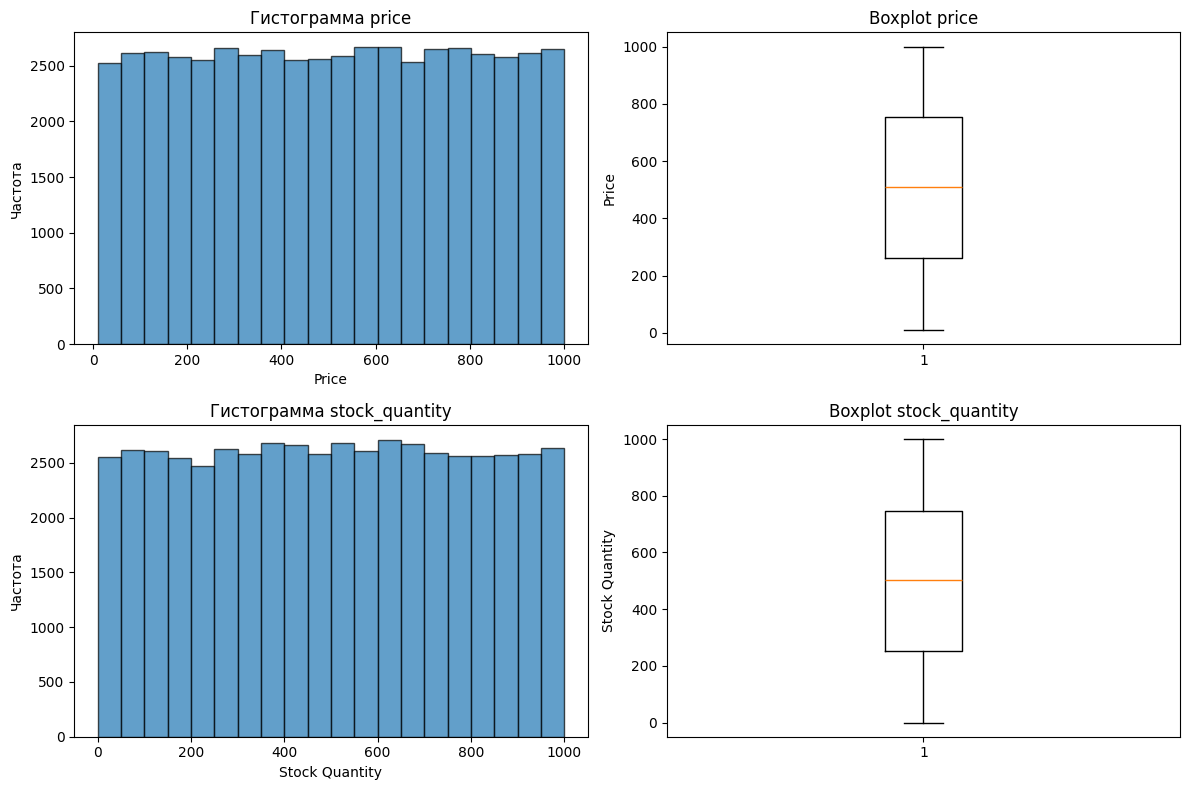

In [45]:
# Гистограммы и Boxplot
# ============================================
# Настройка размера графиков
plt.figure(figsize=(12, 8))

# Гистограмма для price
plt.subplot(2, 2, 1)
plt.hist(products['price'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Гистограмма price')
plt.xlabel('Price')
plt.ylabel('Частота')

# Boxplot для price
plt.subplot(2, 2, 2)
plt.boxplot(products['price'].dropna())
plt.title('Boxplot price')
plt.ylabel('Price')

# Гистограмма для stock_quantity
plt.subplot(2, 2, 3)
plt.hist(products['stock_quantity'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Гистограмма stock_quantity')
plt.xlabel('Stock Quantity')
plt.ylabel('Частота')

# Boxplot для stock_quantity
plt.subplot(2, 2, 4)
plt.boxplot(products['stock_quantity'].dropna())
plt.title('Boxplot stock_quantity')
plt.ylabel('Stock Quantity')

plt.tight_layout()
plt.show()

Оба признака имеют почти одинаковые статистики:

 - Средние ~500-507
 - Медианы ~502-508
 - Стандартное отклонение ~286-288
 - Диапазоны ~0-1000

✅ Распределение близко к нормальному (симметричное)
✅ Нет выбросов, судя по квартилям

Корреляция Пирсона:
                   price  stock_quantity
price           1.000000        0.000815
stock_quantity  0.000815        1.000000


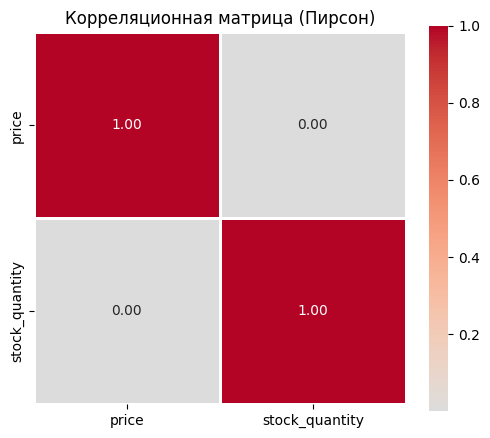

In [46]:
# Корреляционная матрица

pearson_corr = products[['price', 'stock_quantity']].corr()
print("Корреляция Пирсона:")
print(pearson_corr)

# Визуализация корреляционной матрицы
plt.figure(figsize=(6, 5))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', linewidths=1)
plt.title('Корреляционная матрица (Пирсон)')
plt.show()

Корреляция практически равна 0 (0.000815), что говорит о полном отсутствии линейной зависимости между ценой товара и его количеством на складе.

## 4. Выгрузка обработанных данных

In [52]:
import os

output_dir = 'exported_csv'
os.makedirs(output_dir, exist_ok=True)

# Фильтрация по дате: только заказы с 01.01.2025 по 01.06.2025
orders_filtered = orders[
    (orders['order_date'] >= '2025-01-01') &
    (orders['order_date'] <= '2025-06-01')
]

# Выгружаем отфильтрованные заказы
orders_filtered.to_csv(os.path.join(output_dir, 'orders_filtered.csv'), sep=";", index=False)
print(f"✓ orders_filtered: {len(orders_filtered)} строк")

# Фильтруем и выгружаем order_items по отфильтрованным заказам
filtered_order_ids = orders_filtered['order_id'].unique()
order_items_filtered = order_items[order_items['order_id'].isin(filtered_order_ids)]
order_items_filtered.to_csv(os.path.join(output_dir, 'order_items_filtered.csv'), sep=";", index=False)
print(f"✓ order_items_filtered: {len(order_items_filtered)} строк")

# Выгружаем все остальные таблицы полностью
products.to_csv(os.path.join(output_dir, 'products.csv'), sep=";", index=False)
users.to_csv(os.path.join(output_dir, 'users.csv'), sep=";", index=False)
categories.to_csv(os.path.join(output_dir, 'categories.csv'), sep=";", index=False)
reviews.to_csv(os.path.join(output_dir, 'reviews.csv'), sep=";", index=False)
transactions.to_csv(os.path.join(output_dir, 'transactions.csv'), sep=";", index=False)

print("\n✅ Все таблицы выгружены в папку: 'exported_csv'")
print(f"\nИтог:")
print(f"  - orders_filtered.csv (отфильтрован по дате)")
print(f"  - order_items_filtered.csv (отфильтрован по order_id)")
print(f"  - products.csv (полный)")
print(f"  - users.csv (полный)")
print(f"  - categories.csv (полный)")
print(f"  - reviews.csv (полный)")
print(f"  - transactions.csv (полный)")

✓ orders_filtered: 246456 строк
✓ order_items_filtered: 739873 строк

✅ Все таблицы выгружены в папку: 'exported_csv'

Итог:
  - orders_filtered.csv (отфильтрован по дате)
  - order_items_filtered.csv (отфильтрован по order_id)
  - products.csv (полный)
  - users.csv (полный)
  - categories.csv (полный)
  - reviews.csv (полный)
  - transactions.csv (полный)
